# Familias de soluciones de EDOs · Métodos Matemáticos I
**César Acosta**

Este cuaderno dibuja, para cada ecuación diferencial de las hojas, **todas las curvas integrales** (una por cada valor de la constante),
resalta **una concreta** (la que eliges), y también dibuja **soluciones paramétricas** y **trayectorias ortogonales**.

Todo son funciones: solo hay que llamarlas.

| Quiero dibujar… | Función |
|---|---|
| un ejercicio de las hojas | `plot_problem("h3-17")` |
| una hoja entera (miniaturas) | `plot_sheet(1)` |
| una solución implícita `F(x,y)=C` | `plot_level(...)` |
| una solución explícita `y=f(x;C)` | `plot_explicit(...)` |
| una solución paramétrica `x(p), y(p)` | `plot_param(...)` |
| una familia y sus ortogonales | `plot_orthogonal(...)` |
| solo tengo la EDO (sin resolver) | `plot_ode(...)` |
| mover las constantes con sliders | `interactive("h3-17")` |
| figuras para el LaTeX | `export_figures(...)` |

Las expresiones se escriben como texto: `+ - * / ^`, `sin cos tan asin acos atan sinh cosh tanh exp log sqrt cbrt abs`, constantes `pi` y `e`.
**No hay multiplicación implícita**: escribe `2*x`, no `2x`.

In [1]:
import sys
try:
    import edoviz
except ModuleNotFoundError:                 # si no has hecho `pip install -e .`, usa la carpeta del repositorio
    sys.path.insert(0, "..")
from edoviz import *

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

## 1 · Un ejercicio del catálogo
`h1-01` = Hoja 1, ejercicio 1. Las curvas finas son la familia completa (todas las constantes posibles); la gruesa es la que tiene el valor
elegido de la constante. Cambia ese valor con `values=`.

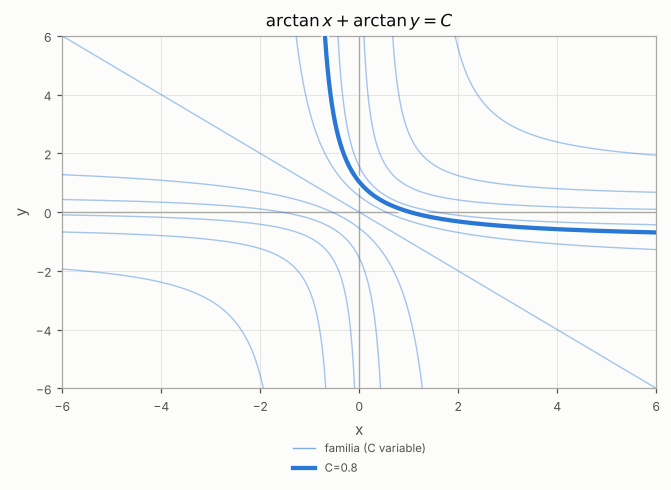

In [2]:
plot_problem("h1-01")

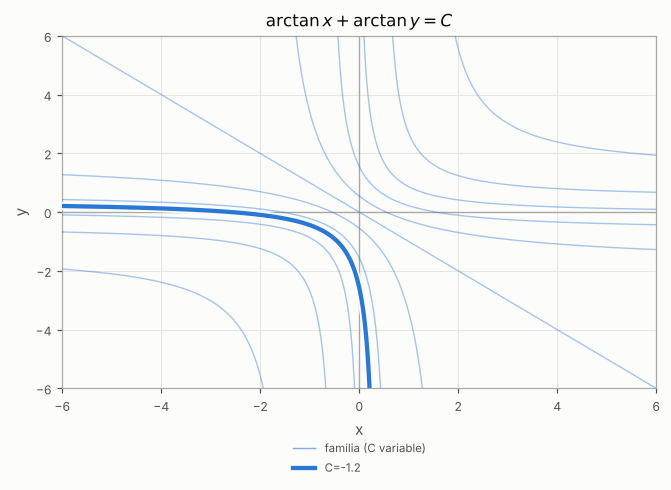

In [3]:
plot_problem("h1-01", values={"C": -1.2})

Con condición inicial, la solución particular sale en verde (aquí Hoja 1, ejercicio 3: `y' sin x − y cos x = 0`, `y(π/2)=1`). Con `field=True` se añade el campo de direcciones.

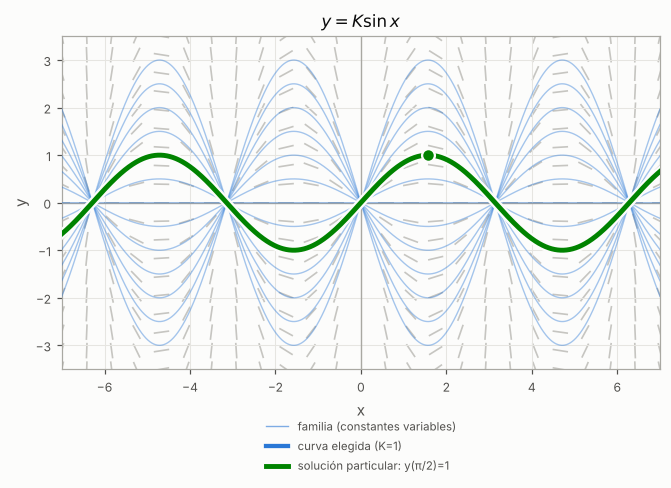

In [4]:
plot_problem("h1-03", field=True)

## 2 · Tus propias soluciones
Solo escribes la solución. El rango de cada constante es `(mínimo, máximo, valor_resaltado)`.

### Implícitas  `F(x,y) = C`
`x dx + y dy = 0  ⟹  x² + y² = C`

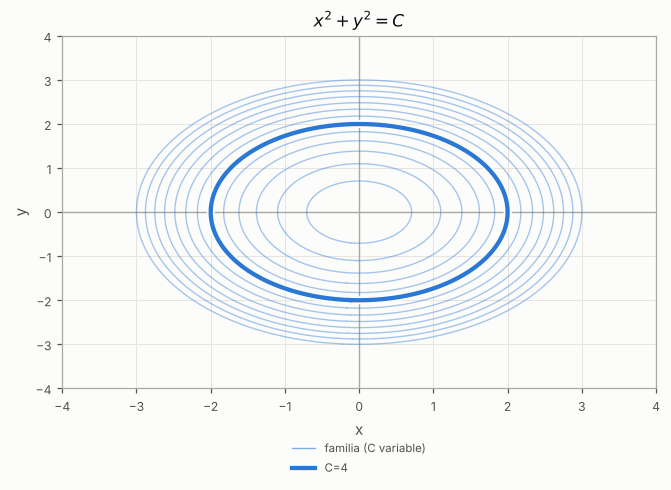

In [5]:
plot_level("x^2 + y^2", C=(0.5, 9, 4), window=(-4, 4, -4, 4), tex=r"x^2+y^2=C")

Si la solución tiene otras constantes (aquí `a`), también se pasan como argumentos: `y' = a^(x+y)  ⟹  a^x + a^(−y) = K`.

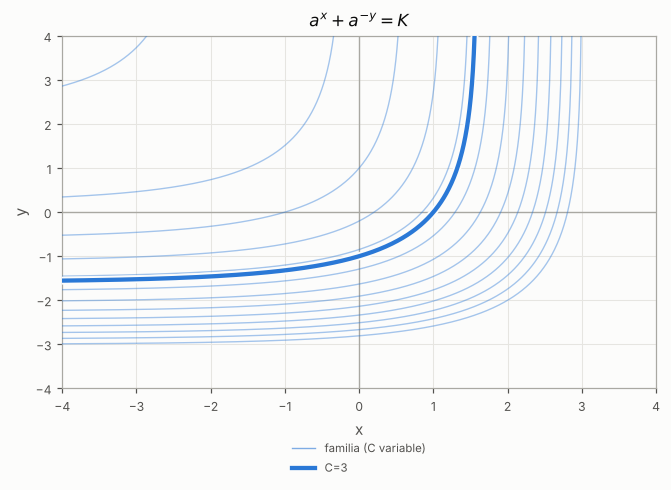

In [6]:
plot_level("a^x + a^(-y)", C=(0.2, 8, 3), a=(0.2, 4, 2), window=(-4, 4, -4, 4), tex=r"a^x+a^{-y}=K")

### Explícitas  `y = f(x; C)`
`y' = −2xy  ⟹  y = C e^{−x²}`

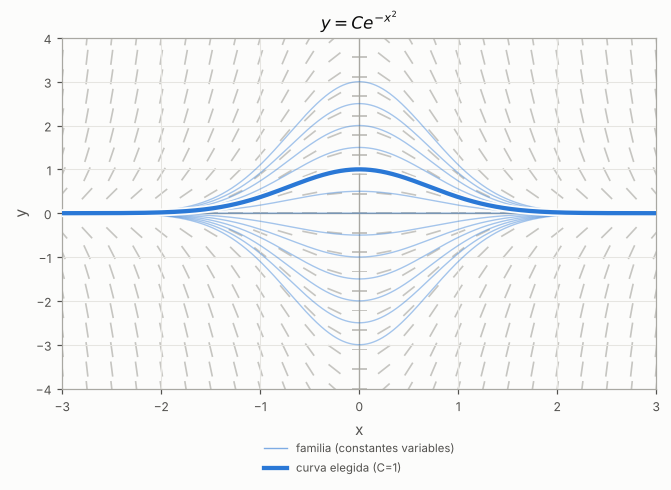

In [7]:
plot_explicit("C*exp(-x^2)", C=(-3, 3, 1), window=(-3, 3, -4, 4), slope="-2*x*y", field=True, tex=r"y=Ce^{-x^2}")

Varias ramas (±) y dominio: `y² = (sin x + C)/ln x` (Hoja 2, ej. 14).

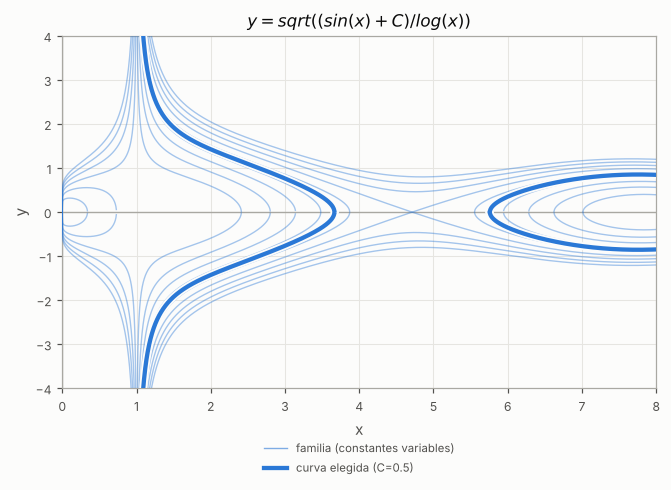

In [8]:
plot_explicit(["sqrt((sin(x)+C)/log(x))", "-sqrt((sin(x)+C)/log(x))"], C=(-2, 2, 0.5), window=(0, 8, -4, 4))

### Paramétricas  `x(p), y(p)`
EDOs de Lagrange/Clairaut (Hoja 3): `y = (y')² e^{y'}` da `x = (p+1)eᵖ + C`, `y = p² eᵖ`. Cambiar `C` desplaza la curva.

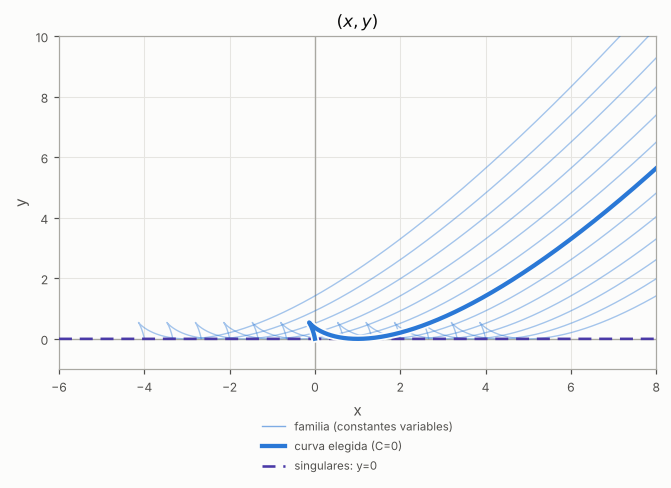

In [9]:
plot_param("(p+1)*exp(p) + C", "p^2*exp(p)", var="p", t=(-10, 2.2), C=(-4, 4, 0), window=(-6, 8, -1, 10),
           extras=[dict(kind="explicit", y="0", label="y=0")])

Clairaut con solución singular (envolvente): `y = x y' + a/(y')²`  ⟹  `y = Cx + a/C²` y `4y³ = 27a x²` (línea discontinua).

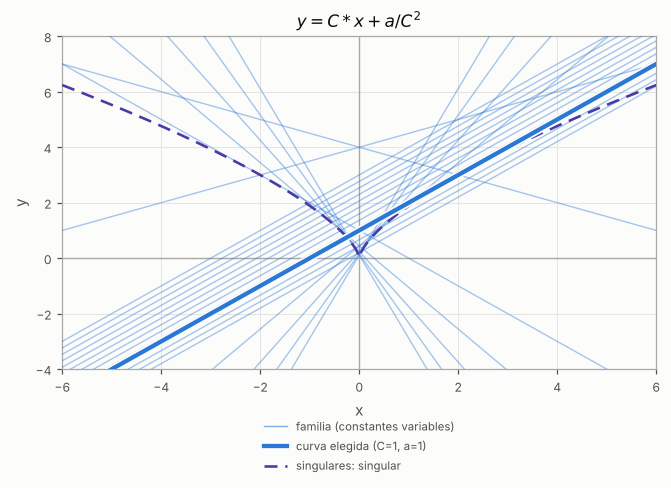

In [10]:
plot_explicit("C*x + a/C^2", C=(-3, 3, 1), a=(0.2, 3, 1), window=(-6, 6, -4, 8),
              extras=[dict(kind="explicit", y="3*cbrt(a*x^2/4)", label="singular")])

### Trayectorias ortogonales
Se da la familia `F1(x,y) = a` y su ortogonal `F2(x,y) = C`. Se dibujan a la vez, se resaltan una de cada y se marcan los puntos de corte (ángulo de 90°).

Ejemplo: `y = a xⁿ` es ortogonal a `x² + n y² = C`.

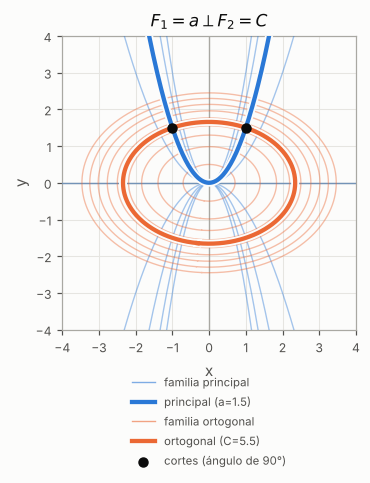

In [11]:
plot_orthogonal("y/x^n", "x^2 + n*y^2", n=(0.5, 4, 2), a=(-3, 3, 1.5), C=(0.5, 12, 5.5), window=(-4, 4, -4, 4))

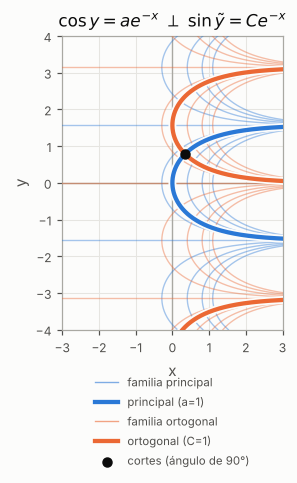

In [12]:
plot_problem("h3-20")

## 3 · Solo tengo la EDO (sin solución cerrada)
`plot_ode` integra la EDO numéricamente (Runge–Kutta) desde muchos puntos y dibuja el campo de direcciones.
`slope="..."` para `y' = f(x,y)`; o `M="..", N=".."` para `M dx + N dy = 0`. `highlight=(x0, y0)` resalta la curva por ese punto.

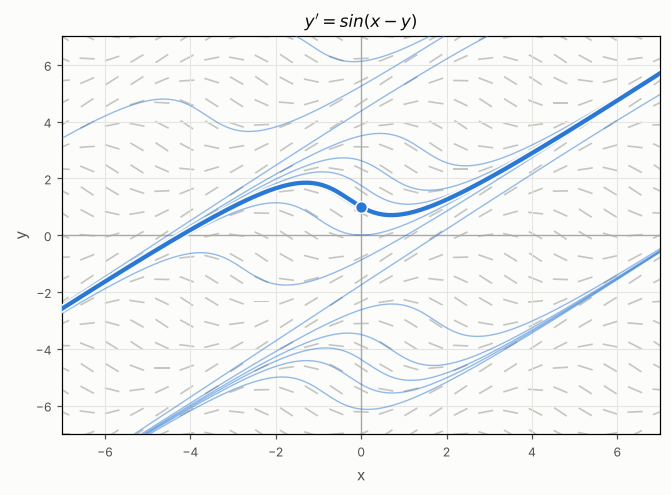

In [13]:
plot_ode(slope="sin(x - y)", window=(-7, 7, -7, 7), highlight=(0, 1))

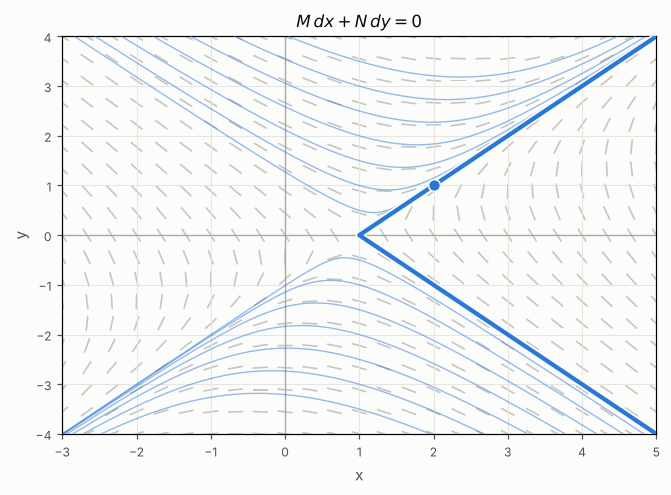

In [14]:
plot_ode(M="3*y - 7*x + 7", N="-(3*x - 7*y - 3)", window=(-3, 5, -4, 4), highlight=(2, 1))   # Hoja 1, ej. 20

## 4 · Hoja completa

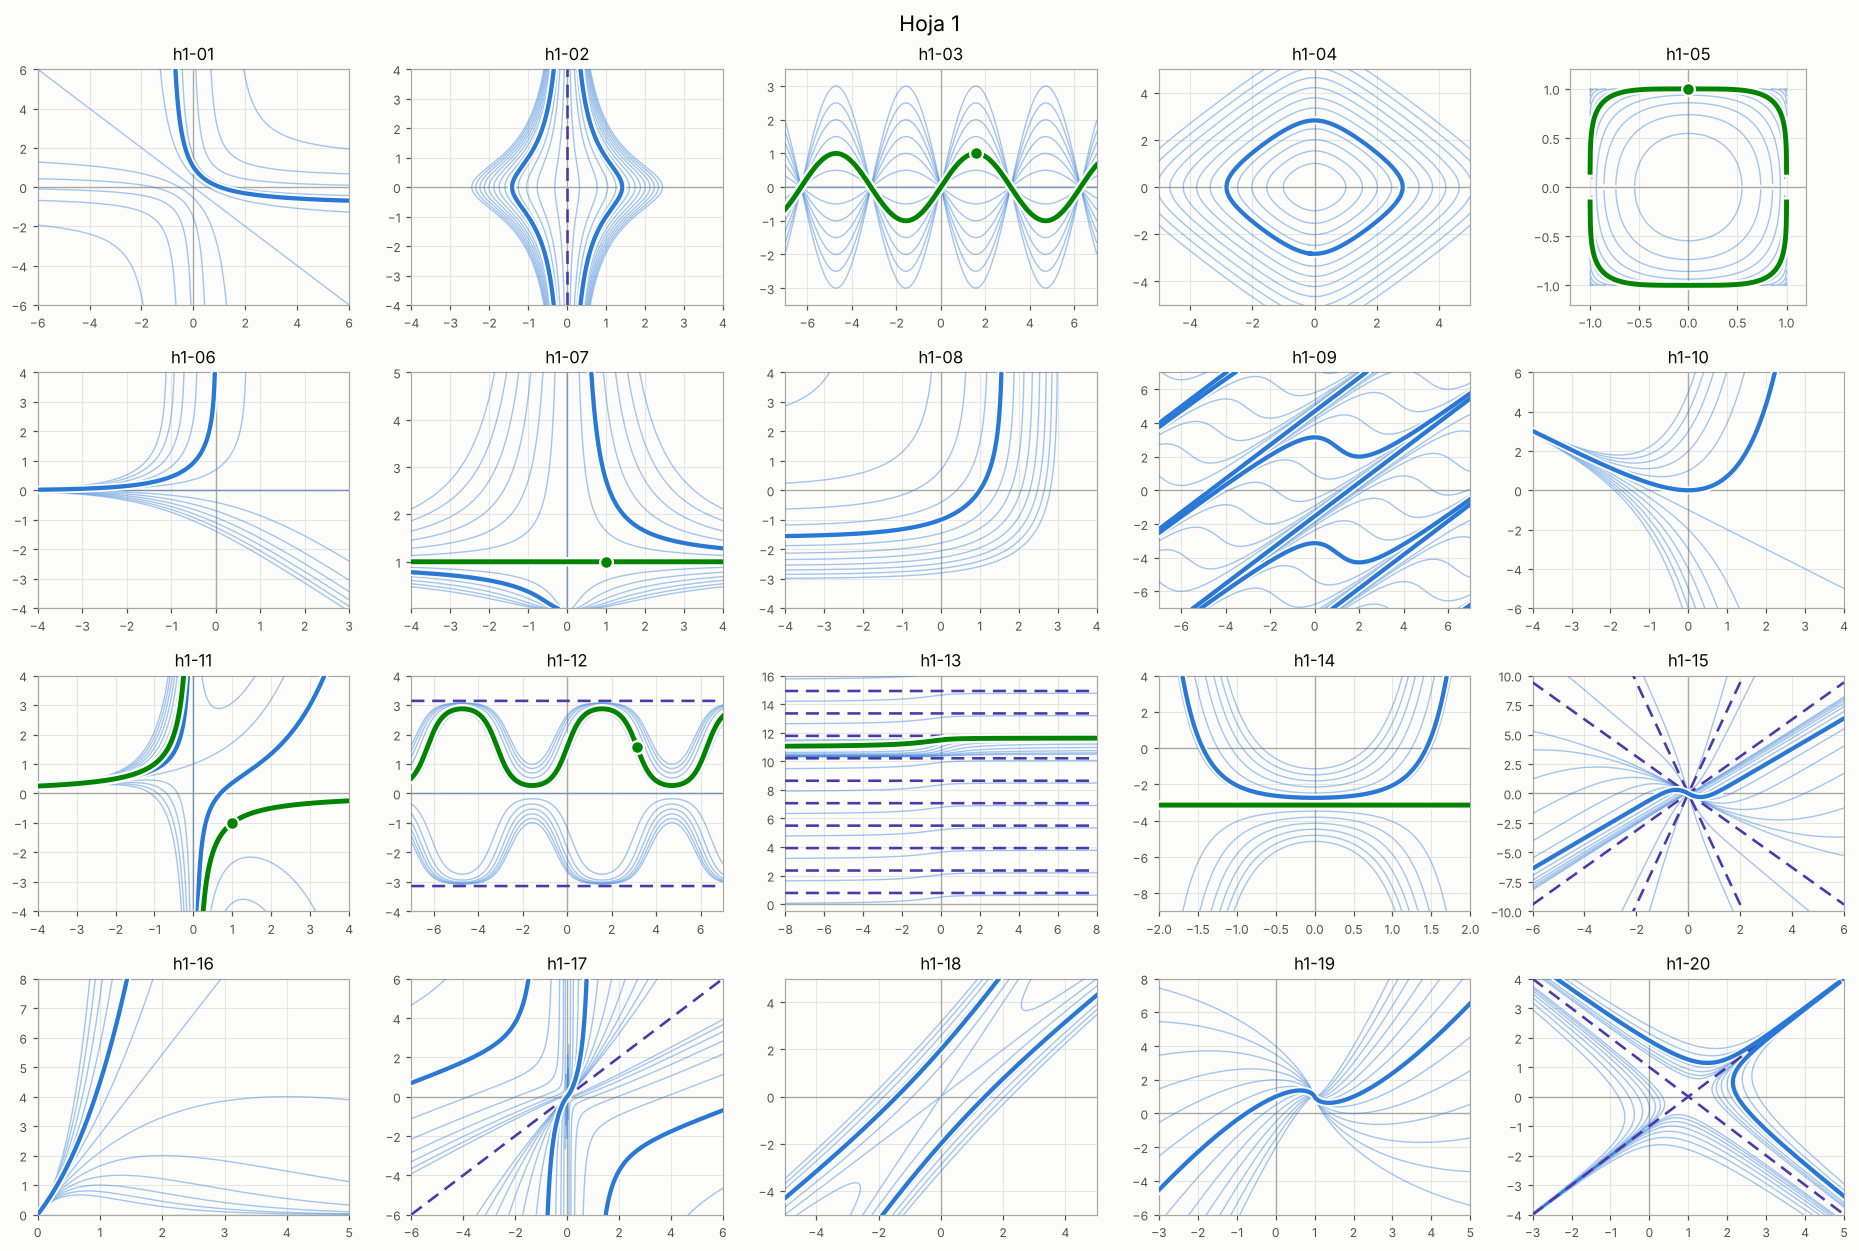

In [15]:
plot_sheet(1, cols=5)

## 5 · Sliders dentro de Jupyter
Mueve las constantes y la curva elegida se resalta. (Necesita `ipywidgets`; en GitHub no se ve, hay que abrir el cuaderno en Jupyter/VS Code. La versión para navegador está en la web.)

In [16]:
interactive("h3-17")

Output()

## 6 · Figuras para el informe en LaTeX
`export_figures` guarda un PDF vectorial por ejercicio en `figs/`; `patch_latex` crea una **copia** del `.tex` con cada figura
(`\includegraphics`) al final de su ejercicio. El original no se toca.

In [17]:
files = export_figures("../figs", sheets=[1, 2, 3])          # figs/h1-01.pdf ... h3-20.pdf
print(len(files), "figuras, p. ej.", files[0].name)
n = patch_latex("../tex/Metodos_Matematicos_I.tex", "../tex/Metodos_Matematicos_I_con_graficas.tex", figdir="../figs")
print(n, "figuras insertadas en el .tex")

60 figuras, p. ej. h1-01.pdf
60 figuras insertadas en el .tex


Constantes concretas por ejercicio al exportar: `export_figures("../figs", ids=["h3-17"], values={"h3-17": {"a": 2, "C": 8}})`.

## 7 · Añadir una hoja nueva
1. Escribe el LaTeX de la Hoja 4 en `tex/Metodos_Matematicos_I.tex`.
2. Añade una entrada por ejercicio en `edoviz/catalog.py` (copia una parecida). Por ejemplo:
```python
level("h4-01", "x^2*y", K("C", -5, 5, 1), [-4, 4, -4, 4], r"x^2y=C", slope="-2*y/x")
```
3. Comprueba que tu solución cumple la EDO (derivación simbólica): `python -m edoviz.check h4-01`
   (usa `ode="..."`, con `y1`, `y2`, `y3` = derivadas, cuando no des `slope`).
4. Regenera la web: `python scripts/build_site.py`.